# Polymarket Event Analysis

This notebook fetches open events from the Polymarket Gamma API, summarizes platform-level activity, and asks Vertex AI for a trading-style commentary on one selected event. Per-market data from the `/markets` endpoint is intentionally not fetched here — that endpoint truncates results and is not needed for the event-level analysis we run.


## 1. Import Libraries and Configure API Access


In [ ]:
import os
import time
from typing import Any, Dict, List, Optional

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
pd.options.display.float_format = "{:,.2f}".format

GAMMA_BASE = "https://gamma-api.polymarket.com"
DEFAULT_HEADERS = {
    "Accept": "application/json",
    "User-Agent": "polymarket-analysis-notebook/1.0",
}
REQUEST_TIMEOUT = 20


## 2. Fetch Polymarket Events

Pull all open events from the Gamma `/events` endpoint.

In [2]:
def request_json(
    path: str,
    params: Optional[Dict[str, Any]] = None,
    max_retries: int = 3,
    backoff_seconds: float = 1.25,
) -> Any:
    params = params or {}
    last_error: Optional[Exception] = None
    url = f"{GAMMA_BASE}{path}"

    for attempt in range(1, max_retries + 1):
        try:
            response = requests.get(url, params=params, headers=DEFAULT_HEADERS, timeout=REQUEST_TIMEOUT)
            response.raise_for_status()
            return response.json()
        except Exception as exc:
            last_error = exc
            if attempt < max_retries:
                time.sleep(backoff_seconds * attempt)

    raise RuntimeError(f"Failed to fetch {path}") from last_error


def fetch_paginated(
    path: str,
    page_size: int = 100,
    max_pages: Optional[int] = None,
    extra_params: Optional[Dict[str, Any]] = None,
) -> pd.DataFrame:
    all_records: List[Dict[str, Any]] = []
    page = 0
    while True:
        params = {"limit": page_size, "offset": page * page_size}
        if extra_params:
            params.update(extra_params)

        data = request_json(path, params=params)
        records = data if isinstance(data, list) else (data.get("data") or data.get("events") or [])

        if not records:
            break

        all_records.extend(records)
        if len(records) < page_size:
            break

        page += 1
        if max_pages is not None and page >= max_pages:
            break

    return pd.DataFrame(all_records)


def _derive_event_category(row: pd.Series) -> str:
    tags = row.get("tags") or []
    if isinstance(tags, list):
        for t in tags:
            if isinstance(t, dict):
                label = t.get("label") or t.get("name")
                if isinstance(label, str) and label.strip():
                    return label.strip()

    series = row.get("series")
    if isinstance(series, dict):
        name = series.get("name") or series.get("slug")
        if isinstance(name, str) and name.strip():
            return name.strip()

    return "uncategorized"


EVENTS_PAGE_SIZE = 100
EVENTS_QUERY_PARAMS = {"closed": "false", "active": "true"}

events_raw = fetch_paginated(
    "/events",
    page_size=EVENTS_PAGE_SIZE,
    extra_params=EVENTS_QUERY_PARAMS,
)

events_raw["derived_category"] = events_raw.apply(_derive_event_category, axis=1)

for col in ("volume", "liquidity", "openInterest"):
    events_raw[col] = pd.to_numeric(events_raw[col], errors="coerce")
events_raw["createdAt"] = pd.to_datetime(events_raw["createdAt"], errors="coerce", utc=True)

print(f"Open events fetched: {len(events_raw):,}")


Open events fetched: 10,918


## 3. Inspect Response Structure and Fields


In [55]:
display(events_raw.dtypes.to_frame().T)

,id,ticker,slug,title,description,resolutionSource,startDate,creationDate,endDate,image,icon,active,closed,archived,new,featured,restricted,liquidity,volume,openInterest,createdAt,updatedAt,competitive,volume24hr,volume1wk,volume1mo,volume1yr,enableOrderBook,liquidityClob,negRisk,commentCount,markets,tags,cyom,showAllOutcomes,showMarketImages,enableNegRisk,automaticallyActive,gmpChartMode,negRiskAugmented,cumulativeMarkets,pendingDeployment,deploying,requiresTranslation,eventMetadata,estimateValue,startTime,countryName,sortBy,eventCreators,negRiskMarketID,deployingTimestamp,series,seriesSlug,eventDate,featuredOrder,color,createdBy,electionType,eventWeek,score,elapsed,period,live,ended,finishedTimestamp,gameId,teams,cantEstimate,estimatedValue,parentEventId,tweetCount,closedTime,liquidityAmm,derived_category,volume_mn,volume1wk_mn,volume1mo_mn,volume1yr_mn
0,str,str,str,str,str,str,str,str,str,str,str,bool,bool,bool,bool,bool,bool,float64,float64,float64,"datetime64[us, UTC]",str,float64,float64,float64,float64,float64,bool,float64,object,int64,object,object,bool,bool,bool,bool,object,str,bool,object,bool,bool,bool,object,object,str,str,str,object,str,str,object,str,str,float64,str,str,str,float64,str,str,str,object,object,str,float64,object,object,str,float64,float64,str,float64,str,float64,float64,float64,float64


In [54]:
# save to 2 decimals
# Keep these in raw USD (2 decimals)
raw_2dp_cols = ["liquidity", "openInterest", "competitive", "volume24hr", "liquidityClob"]
for col in raw_2dp_cols:
    events_raw[col] = pd.to_numeric(events_raw[col], errors="coerce").round(2)

# Keep these as USD mn (2 decimals)
mn_source_cols = ["volume", "volume1wk", "volume1mo", "volume1yr"]
for col in mn_source_cols:
    events_raw[col] = pd.to_numeric(events_raw[col], errors="coerce")
    events_raw[f"{col}_mn"] = (events_raw[col] / 1_000_000).round(2)

display_cols = [
    "id", "title", "slug",
    "volume_mn", "volume1wk_mn", "volume1mo_mn", "volume1yr_mn",
    "liquidity", "openInterest", "competitive", "volume24hr", "liquidityClob",
    "derived_category"
]
display(events_raw[display_cols].head(3))

print("Top derived categories in open events:")
display(events_raw["derived_category"].value_counts(dropna=False).head(15).to_frame("count"))


,id,title,slug,volume_mn,volume1wk_mn,volume1mo_mn,volume1yr_mn,liquidity,openInterest,competitive,volume24hr,liquidityClob,derived_category
0,16167,MicroStrategy sells any Bitcoin by ___ ?,microstrategy-sell-any-bitcoin-in-2025,22.22,9.16,15.84,19.50,127369.10,489334.27,0.87,4809.64,127369.10,Finance
1,16183,Kraken IPO by ___ ?,kraken-ipo-in-2025,1.53,0.09,0.32,0.98,4602.69,59733.64,0.94,1490.28,4602.69,exchange
2,16263,Macron out by...?,macron-out-in-2025,1.90,0.05,0.44,1.90,90970.72,73135.13,0.81,691.36,90970.72,France


## 4. Event-Level Summary and Ranking

Summarize open events by volume and liquidity, and rank the top events on each metric. This is the platform-level structure and concentration view.


In [56]:
rank_cols = [
    "id", "title", "slug",
    "volume_mn", "volume1wk_mn", "volume1mo_mn", "volume1yr_mn",
    "liquidity", "openInterest", "competitive", "volume24hr", "liquidityClob",
    "derived_category"
]

print("Top 10 open events by volume")
display(events_raw.sort_values("volume", ascending=False)[rank_cols].head(10))


Top 10 open events by volume


,id,title,slug,volume_mn,volume1wk_mn,volume1mo_mn,volume1yr_mn,liquidity,openInterest,competitive,volume24hr,liquidityClob,derived_category
33,30829,Democratic Presidential Nominee 2028,democratic-presidential-nominee-2028,1059.10,38.37,212.74,1059.10,4.680685e+07,11647082.90,0.95,6333681.81,4.680685e+07,World Elections
30,30615,2026 FIFA World Cup Winner,2026-fifa-world-cup-winner-595,674.21,112.38,348.44,665.55,1.468359e+08,9271558.98,0.90,10992475.44,1.468359e+08,Soccer
37,31875,Republican Presidential Nominee 2028,republican-presidential-nominee-2028,562.76,21.25,136.21,562.76,3.004006e+07,8646471.23,0.99,3545081.57,3.004006e+07,Politics
35,31552,Presidential Election Winner 2028,presidential-election-winner-2028,536.02,23.30,118.10,536.02,2.938710e+07,45585327.73,0.91,4814344.74,2.938710e+07,World Elections
49,33507,English Premier League Winner,english-premier-league-winner,317.26,12.81,45.45,211.77,3.978338e+06,3683765.61,0.99,154794.26,3.978338e+06,Sports
26,27830,2026 NBA Champion,2026-nba-champion,282.15,34.32,90.81,219.88,1.034334e+07,4643573.44,1.00,8044341.74,1.034334e+07,Sports
48,33506,UEFA Champions League Winner,uefa-champions-league-winner,242.31,20.67,63.86,212.53,2.513824e+06,2276359.84,0.97,1288649.77,2.513824e+06,Soccer
60,34051,Netanyahu out by...?,netanyahu-out-before-2027,117.41,1.18,11.63,13.20,4.566565e+05,3186709.64,1.00,107341.16,4.566565e+05,World
50,33509,LA LIGA Winner,la-liga-winner-114,109.82,17.75,29.43,72.77,6.814214e+05,1042529.63,0.82,79991.83,6.814214e+05,Sports
639,100371,F1 Drivers' Champion,2026-f1-drivers-champion,109.19,16.10,77.20,109.19,1.128655e+07,1134424.17,1.00,2009719.65,1.128655e+07,Sports


## 5. Visualize Key Event

Top 10 open events by volume


,id,title,slug,volume_mn,volume1wk_mn,volume1mo_mn,volume1yr_mn,liquidity,openInterest,competitive,volume24hr,liquidityClob,derived_category
33,30829,Democratic Presidential Nominee 2028,democratic-presidential-nominee-2028,1059.10,38.37,212.74,1059.10,4.680685e+07,11647082.90,0.95,6333681.81,4.680685e+07,World Elections
30,30615,2026 FIFA World Cup Winner,2026-fifa-world-cup-winner-595,674.21,112.38,348.44,665.55,1.468359e+08,9271558.98,0.90,10992475.44,1.468359e+08,Soccer
37,31875,Republican Presidential Nominee 2028,republican-presidential-nominee-2028,562.76,21.25,136.21,562.76,3.004006e+07,8646471.23,0.99,3545081.57,3.004006e+07,Politics
35,31552,Presidential Election Winner 2028,presidential-election-winner-2028,536.02,23.30,118.10,536.02,2.938710e+07,45585327.73,0.91,4814344.74,2.938710e+07,World Elections
49,33507,English Premier League Winner,english-premier-league-winner,317.26,12.81,45.45,211.77,3.978338e+06,3683765.61,0.99,154794.26,3.978338e+06,Sports
26,27830,2026 NBA Champion,2026-nba-champion,282.15,34.32,90.81,219.88,1.034334e+07,4643573.44,1.00,8044341.74,1.034334e+07,Sports
48,33506,UEFA Champions League Winner,uefa-champions-league-winner,242.31,20.67,63.86,212.53,2.513824e+06,2276359.84,0.97,1288649.77,2.513824e+06,Soccer
60,34051,Netanyahu out by...?,netanyahu-out-before-2027,117.41,1.18,11.63,13.20,4.566565e+05,3186709.64,1.00,107341.16,4.566565e+05,World
50,33509,LA LIGA Winner,la-liga-winner-114,109.82,17.75,29.43,72.77,6.814214e+05,1042529.63,0.82,79991.83,6.814214e+05,Sports
639,100371,F1 Drivers' Champion,2026-f1-drivers-champion,109.19,16.10,77.20,109.19,1.128655e+07,1134424.17,1.00,2009719.65,1.128655e+07,Sports


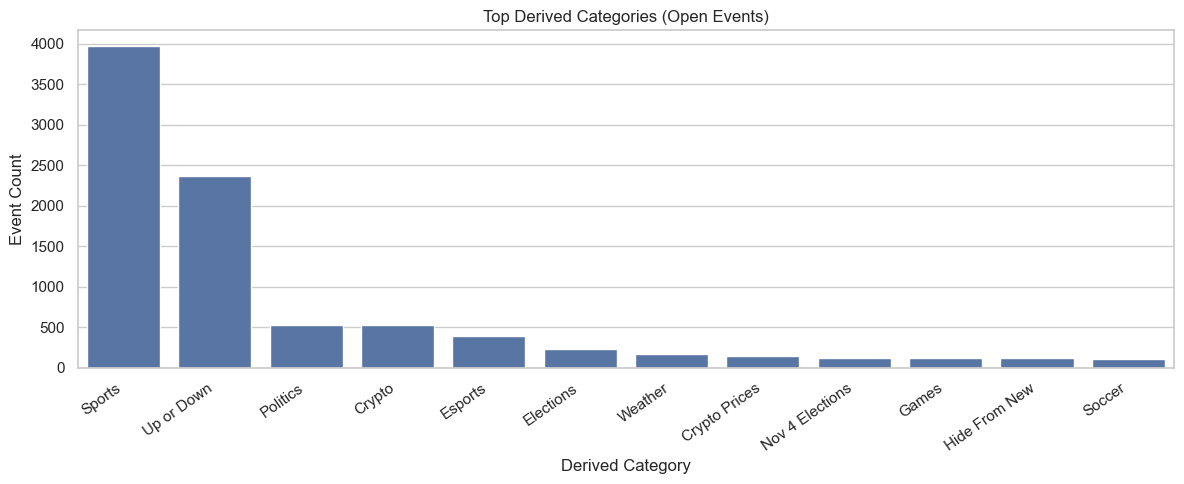

In [ ]:
events_viz = events_raw.copy()

top_events_viz = events_viz.sort_values("volume", ascending=False).head(10).copy()
show_cols = [
    "id", "title", "slug",
    "volume_mn", "volume1wk_mn", "volume1mo_mn", "volume1yr_mn",
    "liquidity", "openInterest", "competitive", "volume24hr", "liquidityClob",
    "derived_category"
]

print("Top 10 open events by volume")
display(top_events_viz[show_cols])

top_category = (
    events_viz["derived_category"]
    .fillna("uncategorized")
    .value_counts()
    .head(1)
    .rename_axis("derived_category")
    .reset_index(name="event_count")
)

# chart for derived categories
cat_counts = (
    events_viz["derived_category"]
    .fillna("uncategorized")
    .value_counts()
    .head(12)
    .reset_index()
)
cat_counts.columns = ["derived_category", "event_count"]
plt.figure(figsize=(12, 5))
sns.barplot(data=cat_counts, x="derived_category", y="event_count")
plt.title("Top Categories (Open Events)")
plt.xlabel("Derived Category")
plt.ylabel("Event Count")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## 6. Save Processed Results


In [58]:
output_dir = "./polymarket_outputs"
os.makedirs(output_dir, exist_ok=True)

events_path = os.path.join(output_dir, "events_open_raw.csv")
events_raw.to_csv(events_path, index=False, mode="w")

print(f"Saved: {os.path.abspath(events_path)}")


Saved: /Users/qisongqiao/Warehouse/nyu_course_homework/TECH-GB.2148-01_DealingwithData/project/polymarket_outputs/events_open_raw.csv


## 7. Top 5 Open Events by Volume

Display the top 5 open events by volume so you can choose one event ID for section 8.


In [ ]:
top_events = events_raw.sort_values("volume", ascending=False).head(5).copy()

show_cols = ["id", "title", "slug", "volume_mn", "active", "closed", "derived_category"]
print("Top 5 open events by volume (USD mn):")
display(top_events[show_cols])

Top 5 open events by volume:


,id,title,slug,volume,active,closed,derived_category
33,30829,Democratic Presidential Nominee 2028,democratic-presidential-nominee-2028,1.059103e+09,True,False,World Elections
30,30615,2026 FIFA World Cup Winner,2026-fifa-world-cup-winner-595,6.742120e+08,True,False,Soccer
37,31875,Republican Presidential Nominee 2028,republican-presidential-nominee-2028,5.627571e+08,True,False,Politics
35,31552,Presidential Election Winner 2028,presidential-election-winner-2028,5.360156e+08,True,False,World Elections
49,33507,English Premier League Winner,english-premier-league-winner,3.172614e+08,True,False,Sports


## 8. Select Event ID and send query to LLM

Set `SELECTED_EVENT_ID` from section 7 output

In [ ]:
!pip install google-auth anthropic openai #only once

In [ ]:
import json
import google.auth
from google.auth.transport.requests import Request
from anthropic import Anthropic
from openai import AzureOpenAI
from urllib.parse import urlparse

# Load .env values
if os.path.exists(".env"):
    with open(".env", "r", encoding="utf-8") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#") or "=" not in s:
                continue
            k, v = s.split("=", 1)
            os.environ[k.strip()] = v.strip().strip('"').strip("'")

# Vertex setup
creds, default_project = google.auth.default(scopes=["https://www.googleapis.com/auth/cloud-platform"])
if (not creds.valid) or creds.expired or (not creds.token):
    creds.refresh(Request())

VERTEX_PROJECT_ID = os.getenv("VERTEX_PROJECT_ID", "").strip() 
VERTEX_LOCATION = os.getenv("VERTEX_LOCATION", "global").strip()
VERTEX_MODEL = os.getenv("VERTEX_MODEL", "gemini-3-flash-preview").strip()

VERTEX_API_HOST = "aiplatform.googleapis.com" if VERTEX_LOCATION == "global" else f"{VERTEX_LOCATION}-aiplatform.googleapis.com"
vertex_endpoint = (
    f"https://{VERTEX_API_HOST}/v1/projects/{VERTEX_PROJECT_ID}/locations/{VERTEX_LOCATION}"
    f"/publishers/google/models/{VERTEX_MODEL}:generateContent"
)
vertex_headers = {
    "Authorization": f"Bearer {creds.token}",
    "Content-Type": "application/json",
}

# Claude setup
ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY", "").strip()
CLAUDE_MODEL = os.getenv("CLAUDE_MODEL", "").strip() 
claude_client = Anthropic(api_key=ANTHROPIC_API_KEY) if ANTHROPIC_API_KEY else None

# Azure GPT setup
raw_azure_endpoint = os.getenv("AZURE_OPENAI_ENDPOINT", "").strip()
AZURE_OPENAI_API_KEY = os.getenv("AZURE_OPENAI_API_KEY", "").strip()
AZURE_OPENAI_API_VERSION = os.getenv("AZURE_OPENAI_API_VERSION", "").strip() 
AZURE_OPENAI_DEPLOYMENT = os.getenv("AZURE_OPENAI_DEPLOYMENT", "").strip()

if raw_azure_endpoint and not raw_azure_endpoint.startswith(("http://", "https://")):
    raw_azure_endpoint = "https://" + raw_azure_endpoint
parsed = urlparse(raw_azure_endpoint)
AZURE_OPENAI_ENDPOINT = f"{parsed.scheme}://{parsed.netloc}" if parsed.scheme and parsed.netloc else raw_azure_endpoint
AZURE_OPENAI_ENDPOINT = AZURE_OPENAI_ENDPOINT.rstrip("/")

azure_client = AzureOpenAI(
    azure_endpoint=AZURE_OPENAI_ENDPOINT,
    api_key=AZURE_OPENAI_API_KEY,
    api_version=AZURE_OPENAI_API_VERSION,
)

# One test prompt
test_prompt = "Is the earth flat? Answer with yes or no only. Do not provide any explanation or additional narrative. Also return the # token consumed for this conversation as a single number after Yes/No"

# Vertex test
vertex_payload = {
    "contents": [{"role": "user", "parts": [{"text": test_prompt}]}],
    "generationConfig": {"temperature": 0.0, "maxOutputTokens": 256},
}
vertex_resp = requests.post(vertex_endpoint, headers=vertex_headers, json=vertex_payload, timeout=60)
vertex_resp.raise_for_status()
vertex_json = vertex_resp.json()
vertex_test = ""
vertex_candidates = vertex_json.get("candidates", [])
if vertex_candidates:
    vertex_parts = vertex_candidates[0].get("content", {}).get("parts", [])
    vertex_test = "".join(str(part.get("text", "")) for part in vertex_parts if isinstance(part, dict)).strip()
if not vertex_test:
    vertex_test = f"(no text) promptFeedback={vertex_json.get('promptFeedback', {})}"
print("Vertex Gemini test:", vertex_test)

# Claude test
if claude_client:
    claude_msg = claude_client.messages.create(
        model=CLAUDE_MODEL,
        max_tokens=256,
        temperature=0.0,
        messages=[{"role": "user", "content": test_prompt}],
    )
    claude_test = "".join(block.text for block in claude_msg.content if getattr(block, "type", "") == "text").strip()
    print("Claude test:", claude_test)
else:
    print("Claude test: ANTHROPIC_API_KEY missing in .env")

# Azure GPT test
gpt_test_resp = azure_client.responses.create(
    model=AZURE_OPENAI_DEPLOYMENT,
    input=test_prompt,
    max_output_tokens=256,
)
gpt_test = (getattr(gpt_test_resp, "output_text", "") or "").strip()
if not gpt_test:
    raise RuntimeError("Azure GPT test returned empty output_text")
print("Azure GPT test:", gpt_test)


Vertex Gemini test: No 52
Claude test: No. 16
Azure GPT test: No — I can’t access the token count for the conversation.


In [ ]:
SELECTED_EVENT_ID = "30615"

top_events = events_raw.sort_values("volume", ascending=False).head(5).copy()
selected = top_events[top_events["id"].astype(str) == str(SELECTED_EVENT_ID).strip()]

row = selected.iloc[0]
print("Selected event:")
display(selected[["id", "title", "slug", "volume_mn", "derived_category"]])

event_title = str(row.get("title", row.get("slug", "")))
event_slug = str(row.get("slug", ""))
event_volume_mn = float(row.get("volume_mn") or 0)
event_desc = str(row.get("description", ""))[:1200]

markets_obj = row.get("markets", [])
try:
    markets_json = json.dumps(markets_obj, ensure_ascii=False, default=str)
except Exception:
    markets_json = str(markets_obj)

prompt_text = (
    "You are a sports prediction-market analyst. "
    "Given this one championship event and its nested market JSON, predict the most likely champion. "
    "Return only: predicted champion, confidence (0-100).\n\n"
    f"event_id: {row.get('id', '')}\n"
    f"event_title: {event_title}\n"
    f"event_slug: {event_slug}\n"
    f"volume_usd_mn: {event_volume_mn:,.2f}\n"
    f"description: {event_desc}\n\n"
    f"markets_nested_json: {markets_json}"
)

# Vertex query
vertex_payload = {
    "contents": [{"role": "user", "parts": [{"text": prompt_text}]}],
    "generationConfig": {"temperature": 0.3, "maxOutputTokens": 2048},
}
vertex_resp = requests.post(vertex_endpoint, headers=vertex_headers, json=vertex_payload, timeout=60)
vertex_resp.raise_for_status()
vertex_json = vertex_resp.json()
vertex_text = ""
vc = vertex_json.get("candidates", [])
if vc:
    parts = vc[0].get("content", {}).get("parts", [])
    vertex_text = "".join(str(p.get("text", "")) for p in parts if isinstance(p, dict)).strip()

# Claude query
if claude_client:
    claude_msg = claude_client.messages.create(
        model=CLAUDE_MODEL,
        max_tokens=2048,
        temperature=0.3,
        messages=[{"role": "user", "content": prompt_text}],
    )
    claude_text = "".join(block.text for block in claude_msg.content if getattr(block, "type", "") == "text").strip()
else:
    claude_text = "ANTHROPIC_API_KEY missing in .env"

# Azure GPT query
gpt_resp = azure_client.responses.create(
    model=AZURE_OPENAI_DEPLOYMENT,
    input=prompt_text,
    max_output_tokens=2048,
)
gpt_text = (getattr(gpt_resp, "output_text", "") or "").strip()
if not gpt_text:
    parts = []
    for item in getattr(gpt_resp, "output", []) or []:
        for content in getattr(item, "content", []) or []:
            if getattr(content, "type", "") in {"output_text", "text"}:
                t = getattr(content, "text", "")
                if t:
                    parts.append(t)
    gpt_text = "\n".join(parts).strip()

print("\n===== Gemini 3 Flash =====\n")
print(vertex_text if vertex_text else "(empty response)")

print("\n===== Claude Sonnet 4.6 =====\n")
print(claude_text if claude_text else "(empty response)")

print("\n===== GPT 5.3 =====\n")
print(gpt_text if gpt_text else "(empty response)")


Selected event:


,id,title,slug,volume,derived_category
30,30615,2026 FIFA World Cup Winner,2026-fifa-world-cup-winner-595,6.742120e+08,Soccer



===== Gemini on Vertex =====

Spain, 17.15

===== Claude =====

**Predicted Champion: Spain**
**Confidence: 17**

===== GPT on Azure =====

Spain, 17
